# Periodicity Search with Lasair

## Get TNS data

In [ ]:
import numpy as np
import pandas as pd

tns_filename = 'tns_public_objects_until_20250916.csv'
tns = pd.read_csv(tns_filename)
tns = tns[np.logical_and(tns['redshift'] <= 0.05, tns['declination'] > -60)]

sn_typeids = [4, 5, 6, 7, 9, 106]  # SN Ib, Ic, Ib/c, Ic-BL, Ibn, Ia-CSM
tns_ibc = tns[np.isin(tns['typeid'], sn_typeids)]

exclude_names = ['2018ebt', '2018yn']  # seem like CV?
tns_ibc = tns_ibc[~tns_ibc['name'].isin(exclude_names)]

tns_ibc

,objid,name_prefix,name,ra,declination,redshift,typeid,type,reporting_groupid,reporting_group,...,discoverymag,discmagfilter,filter,reporters,time_received,internal_names,Discovery_ADS_bibcode,Class_ADS_bibcodes,creationdate,lastmodified
223,186785,SN,2025vaw,259.986968,24.931626,0.019000,7.0,SN Ic-BL,18.0,ATLAS,...,16.9000,73.0,wide,"J. Tonry, L. Denneau, H. Weiland, R. Siverd (I...",2025-08-23 01:01:14,"ATLAS25kew, ZTF25abkwytp, GOTO25gqc, PS25hlu",2025TNSTR3331....1T,2025TNSCR3383....1M,2025-08-23 01:01:16,2025-09-14 13:25:13
356,187431,SN,2025vzq,349.769999,-8.477634,0.007452,5.0,SN Ic,59.0,GOTO,...,19.2200,120.0,L,"D. O'Neill, K. Ackley, M. Dyer, J. Lyman, K. U...",2025-08-28 13:31:03,"GOTO25glk, ATLAS25kqi, ZTF25abmsmeg, , PS25hld",2025TNSTR3412....1O,2025TNSCR3449....1W,2025-08-28 13:31:05,2025-09-11 20:42:45
539,187120,SN,2025vnr,275.383605,25.338430,0.024834,5.0,SN Ic,48.0,ZTF,...,19.4786,111.0,r,"Jesper Sollerman (SU), Christoffer Fremling (C...",2025-08-27 05:49:17,ZTF25abmhftu,2025TNSTR3397....1S,2025TNSCR3626....1D,2025-08-27 05:49:18,2025-09-08 18:16:28
560,185286,SN,2025svz,227.294001,-6.530128,0.023900,7.0,SN Ic-BL,18.0,ATLAS,...,18.7610,73.0,wide,"J. Tonry, L. Denneau, H. Weiland, R. Siverd (I...",2025-08-01 08:53:36,"ATLAS25irk, GOTO25fru, ZTF25abnzacu",2025TNSTR3022....1T,2025TNSCR3265....1E,2025-08-01 08:53:39,2025-09-08 15:36:29
593,184894,SN,2025shi,342.176185,27.582791,0.031952,9.0,SN Ibn,74.0,ALeRCE,...,20.2915,111.0,r,"F. Forster, F.E. Bauer, G. Pignata, A. Munoz-A...",2025-07-26 19:06:09,"ZTF25abecbib, GOTO25fms, ATLAS25ipf, PS25hie",2025TNSTR2908....1F,"2025TNSCR3056....1D, 2025TNSCR3093....1D",2025-07-26 19:06:15,2025-09-07 17:48:55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171657,11409,SN,2016bau,170.245917,53.173778,0.003856,4.0,SN Ib,0.0,NaN,...,17.8000,1.0,Clear,Ron Arbour,2016-03-14 00:32:20,NaN,2016TNSTR.215....1A,2016TNSCR.224....1B,2016-03-14 00:32:20,2016-03-14 00:32:20
171761,11303,SN,2016aws,154.894230,-1.009060,0.043000,4.0,SN Ib,4.0,Pan-STARRS,...,20.3773,26.0,w,"K. C. Chambers, M. E. Huber, H. Flewelling, E....",2016-03-10 22:54:02,PS16awz,2016TNSTR.197....1C,2016TNSCR.218....1P,2016-03-10 22:54:02,2016-03-10 22:54:02
172105,10958,SN,2016ajo,281.052042,24.158250,0.016000,4.0,SN Ib,10.0,XOSS,...,15.7000,1.0,Clear,"Yi Ding, Wei Gao, Xing Gao",2016-02-22 07:01:50,NaN,2016TNSTR.143....1D,2016TNSCR.233....1T,2016-02-22 07:01:50,2016-02-22 07:01:50
173040,10018,SN,2016P,209.379583,6.097500,0.014600,7.0,SN Ic-BL,12.0,RANSSP,...,16.0000,1.0,Clear,"G. Duszanowicz, M. Zolnowski",2016-01-19 18:31:32,NaN,2016TNSTR..33....1D,2016TNSCR..40....1Z,2016-01-19 16:38:47,2016-01-19 16:38:47


In [2]:
def get_sn_row(name):
    return tns_ibc[tns_ibc['name'] == name].iloc[0]

## Fetch lightcurves with Lasair

In [5]:
import os
from lasair import lasair_client

LASAIR_API_TOKEN_FILE = '/Users/asaf/.lasair_token'

# Create output directory
output_dir = "lasair_lightcurves"
os.makedirs(output_dir, exist_ok=True)

def get_lasair_token():
    try:
        with open(LASAIR_API_TOKEN_FILE, 'r') as f:
            return f.read().strip()
    except FileNotFoundError:
        return None
    
api_token = get_lasair_token()
L = lasair_client(api_token, endpoint="https://lasair-ztf.lsst.ac.uk/api")

In [6]:
import os
import time
import json
from tqdm import tqdm

# Create output directory
output_dir = "lasair_lightcurves"
os.makedirs(output_dir, exist_ok=True)

object_id_map = {}
tns_ibc_narrowed = tns_ibc[:1]

for _, row in tqdm(tns_ibc_narrowed.iterrows(), total=len(tns_ibc_narrowed)):
    name = row['name']
    ra = row['ra']
    dec = row['declination']
    out_path = f"{output_dir}/{name}.json"
    
    if os.path.exists(out_path):
        print(f"Already have {name}, skipping.")
        continue  # already downloaded
        
    try:
        result = L.cone(ra=ra, dec=dec, radius=5, requestType='nearest')
        if result and 'object' in result:
            object_id_map[name] = result['object']
        time.sleep(0.2)  # be polite
    except Exception as e:
        print(f"Error for {name}: {e}")

100%|██████████| 1/1 [00:00<00:00, 1855.07it/s]

Already have 2025vaw, skipping.


In [9]:
# Fetch lightcurves

# Reverse map from objectId to name, only if not already downloaded
new_names = [name for name in tns_ibc_narrowed['name'] if name not in os.listdir(output_dir)]
id_to_new_name = {object_id_map[name]: name for name in new_names if name in object_id_map}
print("Found ", len(id_to_new_name), "new ZTF objects.")

try:
    object_ids = list(id_to_new_name.keys())
    if object_ids == []:
        print("No new objects to fetch.")
    else:
        if len(object_ids) > 10:
            print("Limiting to 10 objects for testing.")
            object_ids = object_ids[:10]
        lightcurves = L.lightcurves(object_ids)
        print("Fetched ", len(lightcurves), "lightcurves.")
        for lc in lightcurves:
            name = id_to_new_name.get(lc['objectId'])
            cands = lc['candidates']
            if lc and name:
                with open(f"{output_dir}/{name}.json", "w") as f:
                    json.dump(lc, f)
except Exception as e:
    print(f"Error fetching lightcurves: {e}")

Found  0 new ZTF objects.
No new objects to fetch.


In [15]:
has_lc = [
    name for name in tns_ibc['name']
    if os.path.exists(os.path.join(output_dir, f"{name}.json"))
]

print(f"{len(has_lc)} / {len(tns_ibc)} tns_ibc objects have lightcurve files.")

439 / 781 tns_ibc objects have lightcurve files.


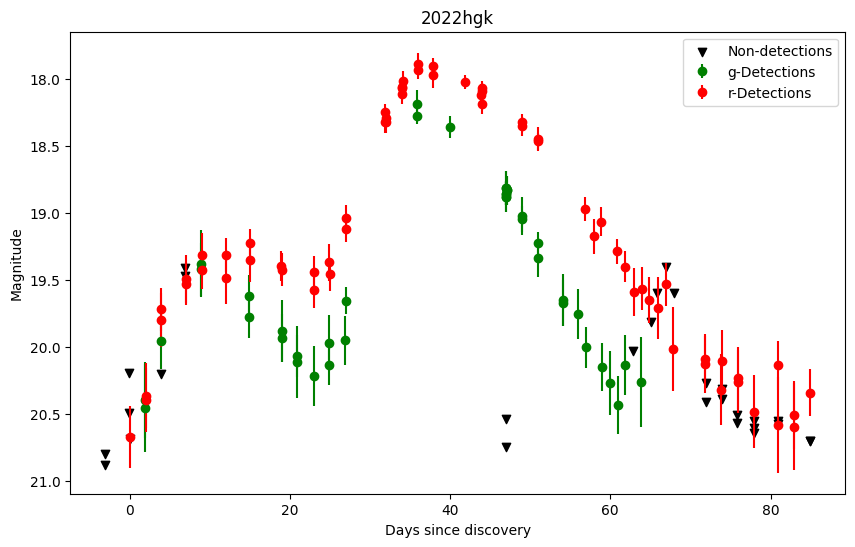

In [25]:
from astropy.time import Time
from lasair_tools import plot_lightcurve

entry = get_sn_row('2022hgk')
plot_lightcurve(entry['name'], Time(entry['discoverydate']).jd, epoch_after_discovery=1000)

## Create a library of candidates

In [18]:
import numpy as np
from astropy.time import Time

from periodicity_tools import get_decline_detections


EPOCH_AFTER_PEAK = 1000
MIN_DETECTINOS_PER_BAND = 20

candidate_library = []

all_peak_mags = []
selected_peaks = []

for name in tns_ibc['name']:

    decline_points = get_decline_detections(name, epoch_after_peak=EPOCH_AFTER_PEAK)
    
    object_all_band_peaks = []
    object_selected_band_peaks = []

    for fid in [1, 2]:
        
        band_data = [p for p in decline_points if p.get('fid') == fid and 'candid' in p]

        if len(band_data) > 0:
            m_all = np.array([p['magpsf'] for p in band_data])
            object_all_band_peaks.append(np.min(m_all))

        if len(band_data) < MIN_DETECTINOS_PER_BAND:
           continue

        t = np.array([p['jd'] for p in band_data])
        m = np.array([p['magpsf'] for p in band_data])
        e = np.array([p['sigmapsf'] for p in band_data])
        
        object_selected_band_peaks.append(np.min(m))

        days = t - t[0]                  
        sn_row = get_sn_row(name)
        peak_after_disc_days = t[0] - Time(sn_row['discoverydate']).jd

        candidate_library.append({
            'name': name, 
            'days_offset': peak_after_disc_days,
            'fid': fid, 
            'days': days,  # days since peak
            'mags': m, 
            'errs': e
        })

    if len(object_all_band_peaks) > 0:
        all_peak_mags.append(np.min(object_all_band_peaks))

    if len(object_selected_band_peaks) > 0:
        selected_peaks.append(np.min(object_selected_band_peaks))

n_cands = len(candidate_library)
n_unique = len(set(entry['name'] for entry in candidate_library))
print(f"Built candidate library with {n_cands} entries.")
print("Number of unique candidates:", n_unique)
print(f"{n_unique} single-band, {n_cands - n_unique} dual-band entries.")

Built candidate library with 116 entries.
Number of unique candidates: 82
82 single-band, 34 dual-band entries.


Total objects with light curves: 439
Total objects with >20 detections in at least one band: 84


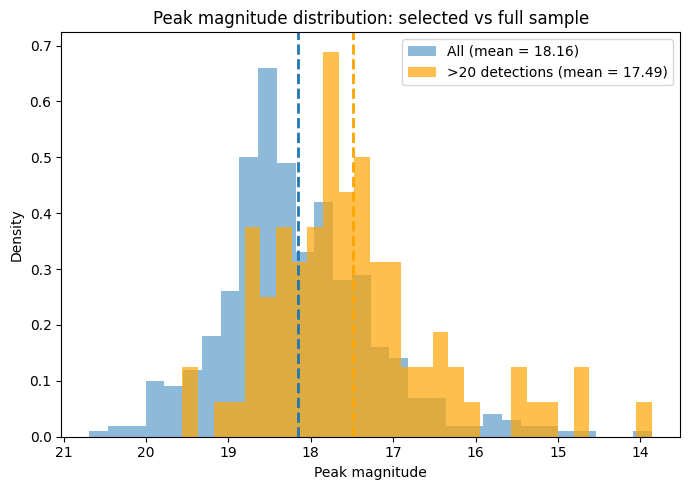

In [90]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.hist(
    all_peak_mags,
    bins=30,
    alpha=0.5,
    density=True,
    color='C0',
    label=f"All (mean = {np.mean(all_peak_mags):.2f})"
)

plt.hist(
    selected_peaks,
    bins=30,
    alpha=0.7,
    density=True,
    color='orange',
    label=f">20 detections (mean = {np.mean(selected_peaks):.2f})"
)

plt.axvline(np.mean(all_peak_mags), linestyle="--", linewidth=2, color='C0')
plt.axvline(np.mean(selected_peaks), linestyle="--", linewidth=2, color='orange')

plt.gca().invert_xaxis()  # brighter magnitudes on the left
plt.xlabel("Peak magnitude")
plt.ylabel("Density")
plt.title("Peak magnitude distribution: selected vs full sample")
plt.legend()
plt.tight_layout()

print("Total objects with light curves:", len(all_peak_mags))
print("Total objects with >20 detections in at least one band:", len(selected_peaks))
plt.savefig("Figures/peak_mag_comparison.pdf", bbox_inches='tight', dpi=300)
plt.show()


### Calculate Global FAP

In [12]:
from collections import defaultdict
from periodicity_tools import MAX_FREQ

p_single_threshold = 1e-4
N_false = 0
Ts = []
M_list = []

use_only_dual_band_targets = False

# Define a more conservative library with only dual bands
bands_per_sn = defaultdict(set)
for entry in candidate_library:
    bands_per_sn[entry["name"]].add(entry["fid"])
dual_band_sne = {
    name for name, bands in bands_per_sn.items()
    if {1, 2}.issubset(bands)
}

for entry in candidate_library:
    
    name = entry["name"]
    if use_only_dual_band_targets and name not in dual_band_sne:
        continue

    days = entry["days"]
    T = days.max() - days.min()
    Ts.append(T)

    f_min = 2 / T
    f_max = MAX_FREQ

    # Effective number of independent frequencies
    M_i = max((f_max - f_min) * T, 0)

    M_list.append(M_i)

    N_false += M_i * p_single_threshold

N_lightcurves = 2 * len(dual_band_sne)

print("Total sample size (light curves):", N_lightcurves)
print("Total expected false alarms in survey:", N_false)
print(f"Fraction of sample: {100 * N_false / N_lightcurves:.3f}%")
print("Min, max T:", np.min(Ts), np.max(Ts))
print("Mean M per light curve:", np.mean(M_list))

Total sample size (light curves): 68
Total expected false alarms in survey: 0.39842690587653806
Fraction of sample: 0.586%
Min, max T: 15.996585600078106 261.664594899863
Mean M per light curve: 33.764992023435404


In [13]:
types = [get_sn_row(name)['typeid'] for name in dual_band_sne]
types_counts = pd.Series(types).value_counts()
print("Type distribution in candidate library:")
print(types_counts)
# SN Ib, Ic, Ib/c, Ic-BL, Ibn, Ia-CSM



Type distribution in candidate library:
4.0      14
5.0      13
7.0       3
106.0     2
9.0       1
6.0       1
Name: count, dtype: int64
Type 106 (Ia-CSM) candidates:
['2022esa', '2020aekp']


## Run survey

In [19]:
from periodicity_tools import analyze_candidate
import importlib
import periodicity_tools
importlib.reload(periodicity_tools)

def run_full_survey(candidate_library):

    grouped_results = {
        "poly3": {},
        "poly4": {},
        "poly5": {},
        "poly6": {},
    }

    methods = ["poly3","poly4","poly5","poly6"]

    for entry in candidate_library:

        name = entry['name']
        fid = entry['fid']
        days = entry['days']
        mags = entry['mags']
        errs = entry['errs']

        res3 = analyze_candidate(name, days, mags, errs, poly_deg=3)
        res4 = analyze_candidate(name, days, mags, errs, poly_deg=4)
        res5 = analyze_candidate(name, days, mags, errs, poly_deg=5)
        res6 = analyze_candidate(name, days, mags, errs, poly_deg=6)

        # Add fid
        for r in [res3, res4, res5, res6]:
            r["fid"] = fid

        # Group by SN name
        for method, res in zip(
            methods,
            [res3, res4, res5, res6]
        ):
            if name not in grouped_results[method]:
                grouped_results[method][name] = []
            grouped_results[method][name].append(res)

    return grouped_results

grouped_results = run_full_survey(candidate_library)

In [13]:
import importlib
import periodicity_tools
importlib.reload(periodicity_tools)

<module 'periodicity_tools' from '/Users/asaf/Documents/sne_periodicity_search/periodicity_tools.py'>

### Find double hits

In [20]:
from periodicity_tools import compute_delta_chi2_curve
from scipy.stats import chi2


SINGLE_FREQ_P = 1e-4

def find_dual_band_hits(grouped_results, candidate_library):
    """
    Search for candidates that show significant periodicity in both bands, with consistent periods.
        Criteria for dual-band hit:
        1. Both bands must have some significant peak p-value < SINGLE_FREQ_P
        2. Both bands must have best amplitude >= MDA (minimal detectable amplitude).
        3. To avoid missing harmonics, the period is chosen based on the stronger Δχ² (out of 2 bands)
             and then we look for a significant peak in the other band within a tolerance of T/P
    """

    methods = ["poly3", "poly4", "poly5", "poly6"]
    double_hits = {method: set() for method in methods}
    updated_grouped = {method: {} for method in methods}

    for method in methods:

        poly_deg = int(method.replace("poly", ""))

        for name, band_results in grouped_results[method].items():

            if len(band_results) < 2:
                continue

            r1, r2 = band_results

            if not (
                r1["p_value_single_freq"] < SINGLE_FREQ_P and
                r2["p_value_single_freq"] < SINGLE_FREQ_P and
                r1["best_amplitude"] >= r1["mda"] and
                r2["best_amplitude"] >= r2["mda"]
            ):
                continue

            # Choose anchor band (stronger Δχ²)
            if r1["delta_chi2"] >= r2["delta_chi2"]:
                anchor = r1
                other = r2
            else:
                anchor = r2
                other = r1

            # Recompute Δχ² curve for the other band
            entry = next(
                e for e in candidate_library
                if e["name"] == name and e["fid"] == other["fid"]
            )

            # Find significant peak in other band within tolerance of anchor period
            freq, dchi2 = compute_delta_chi2_curve(
                entry["days"],
                entry["mags"],
                entry["errs"],
                poly_deg
            )
            periods = 1 / freq

            sig_threshold = chi2.ppf(1 - SINGLE_FREQ_P, df=2)

            P_anchor = anchor["best_period"]
            period_tol = max(r1['time_baseline']/r1['best_period'], r2['time_baseline']/r2['best_period'])
            period_tol = max(r1['best_period']**2/r1['time_baseline'], r2['best_period']**2/r2['time_baseline'])
            tol_mask = np.abs(periods - P_anchor) < period_tol

            if not np.any(tol_mask):
                continue

            dchi2_masked = dchi2[tol_mask]
            periods_masked = periods[tol_mask]
            local_max = (
                (dchi2_masked[1:-1] > dchi2_masked[:-2]) &
                (dchi2_masked[1:-1] > dchi2_masked[2:])
            )
            peak_vals = dchi2_masked[1:-1][local_max]
            peak_periods = periods_masked[1:-1][local_max]
            
            sig_mask = peak_vals > sig_threshold
            if not np.any(sig_mask):
                continue

            best_idx = np.argmax(peak_vals[sig_mask])
            P_match = peak_periods[sig_mask][best_idx]
            dchi2_match = peak_vals[sig_mask][best_idx]

            updated_other = other.copy()
            updated_other["best_period"] = P_match
            updated_other["best_frequency"] = 1.0 / P_match
            updated_other["delta_chi2"] = dchi2_match
            updated_other["p_value_single_freq"] = 1 - chi2.cdf(dchi2_match, df=2)

            updated_grouped[method][name] = [anchor, updated_other]
            double_hits[method].add(name)

    return double_hits, updated_grouped

double_hits, updated_grouped = find_dual_band_hits(grouped_results, candidate_library)
double_hits

{'poly3': {'2020sgf', '2022esa', '2022jli'},
 'poly4': {'2020sgf', '2022esa', '2022jli'},
 'poly5': {'2020sgf', '2022esa', '2022jli'},
 'poly6': {'2020sgf', '2022esa', '2022jli'}}

## Ploting

### Plot lightcurve with fit

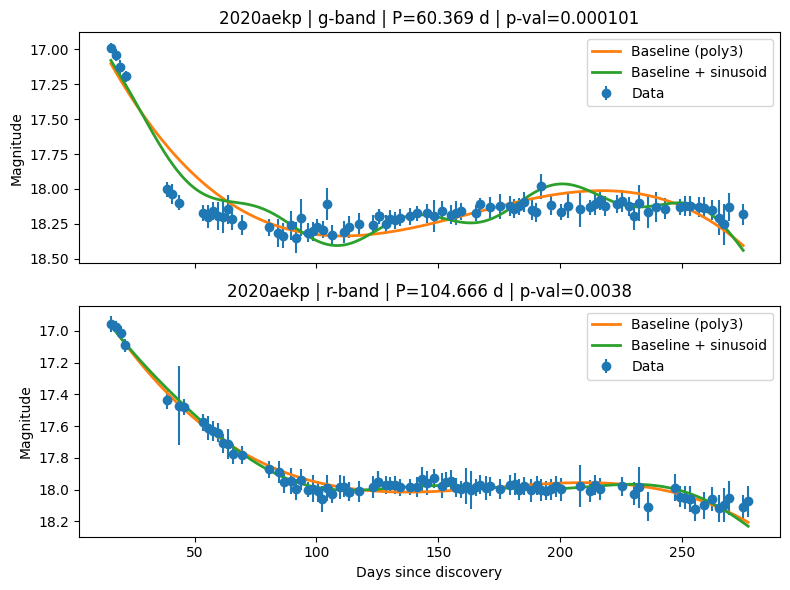

In [16]:
import numpy as np
import matplotlib.pyplot as plt


def plot_from_results(grouped_results, candidate_library, sn_name, method="poly6"):

    grouped = grouped_results[method]
    if sn_name not in grouped:
        print(f"{sn_name} not found.")
        return

    band_results = grouped[sn_name]

    fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

    for ax, res in zip(axes, band_results):

        fid = res["fid"]
        period = res["best_period"]
        pval = res["p_value_single_freq"]

        entry = next(
            e for e in candidate_library
            if e["name"] == sn_name and e["fid"] == fid
        )

        days = entry["days"]
        mags = entry["mags"]
        errs = entry["errs"]
        days_offset = entry["days_offset"]

        t_grid = np.linspace(days.min(), days.max(), 1000)

        poly_model = res["poly_model"]
        full_model = res["full_model"]

        ax.errorbar(days+days_offset, mags, yerr=errs, fmt='o', label="Data")
        ax.plot(days_offset+t_grid, poly_model(t_grid),
                label=f"Baseline ({method})", linewidth=2)
        ax.plot(days_offset+t_grid, full_model(t_grid),
                label="Baseline + sinusoid", linewidth=2)

        ax.invert_yaxis()
        ax.set_ylabel("Magnitude")

        band_str = 'g-band' if fid == 1 else 'r-band'
        pval_str = f"p-val={pval:.3}" if pval > 0 else r"p-val < 1.1e-16"
        ax.set_title(f"{sn_name} | {band_str} | P={period:.3f} d | {pval_str}")
        ax.legend()

    axes[-1].set_xlabel("Days since discovery")

    plt.tight_layout()
    plt.show()
    # for just plotting
    # plt.savefig(f'Figures/{sn_name}_{method}_fit.pdf', dpi=300, bbox_inches='tight')
    
    # for saving all fits
    # plt.savefig(f'Figures/all_fits/{method}/{sn_name}_{method}_fit.png', dpi=120, bbox_inches='tight')
    plt.close(fig)
    
plot_from_results(grouped_results, candidate_library, '2020aekp', method="poly3")

# Save all figs to appendix
# for cand in candidate_library:
#     plot_from_results(grouped_results, candidate_library, cand['name'], method="poly6")

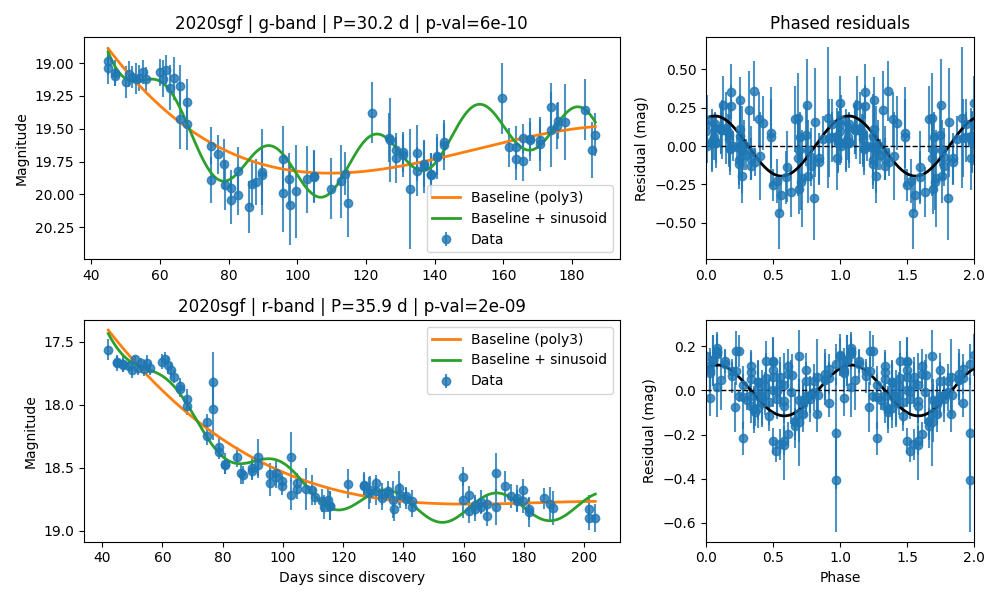

In [102]:

def plot_with_phase(grouped_results, candidate_library, sn_name, method="poly3"):

    grouped = grouped_results[method]
    if sn_name not in grouped:
        print(f"{sn_name} not found.")
        return

    band_results = grouped[sn_name]

    _, axes = plt.subplots(2, 2, figsize=(10, 6),
                             gridspec_kw={"width_ratios": [2, 1]})

    for row, res in enumerate(band_results):

        ax_lc = axes[row, 0]
        ax_phase = axes[row, 1]

        fid = res["fid"]
        period = res["best_period"]
        pval = res["p_value_single_freq"]

        entry = next(
            e for e in candidate_library
            if e["name"] == sn_name and e["fid"] == fid
        )

        days = np.asarray(entry["days"])
        mags = np.asarray(entry["mags"])
        errs = np.asarray(entry["errs"])
        days_offset = entry["days_offset"]

        t_grid = np.linspace(days.min(), days.max(), 1000)

        poly_model = res["poly_model"]
        full_model = res["full_model"]

        # Left panel: Light curve + fits
        ax_lc.errorbar(days + days_offset, mags, yerr=errs,
                       fmt='o', label="Data", alpha=0.8)

        ax_lc.plot(days_offset + t_grid, poly_model(t_grid),
                   label=f"Baseline ({method})", linewidth=2)

        ax_lc.plot(days_offset + t_grid, full_model(t_grid),
                   label="Baseline + sinusoid", linewidth=2)

        ax_lc.invert_yaxis()
        ax_lc.set_ylabel("Magnitude")

        band_str = 'g-band' if fid == 1 else 'r-band'
        pval_str = f"p-val={pval:.1}" if pval > 0 else r"p-val <e-16"
        ax_lc.set_title(f"{sn_name} | {band_str} | P={period:.1f} d | {pval_str}")

        ax_lc.legend()

        # Right panel: Phased residuals
        # period = 32
        residuals = mags - poly_model(days)
        phase = (days % period) / period
        phase_double = np.concatenate([phase, phase + 1])
        residuals_double = np.concatenate([residuals, residuals])
        errs_double = np.concatenate([errs, errs])
        ax_phase.errorbar(phase_double, residuals_double,
                        yerr=errs_double, fmt='o', alpha=0.8)
        
        # Plot best-fit sinusoid
        t_mean = np.mean(days)
        phase_model = np.linspace(0, 2, 1000)
        t_model = phase_model * period
        t_centered_model = t_model - t_mean

        omega = 2 * np.pi / period
        A = res["full_params"][-2]
        B = res["full_params"][-1]
        sin_model = (
            A * np.sin(omega * t_centered_model) +
            B * np.cos(omega * t_centered_model)
        )
        ax_phase.plot(phase_model, sin_model,
                    color='black', lw=2, label="Best-fit sinusoid")

        ax_phase.axhline(0, color='black', ls='--', lw=1)
        ax_phase.set_xlim(0, 2)
        ax_phase.set_ylabel("Residual (mag)")

    axes[-1, 0].set_xlabel("Days since discovery")
    axes[-1, 1].set_xlabel("Phase")
    axes[0, 1].set_title("Phased residuals")

    plt.tight_layout()
    # plt.savefig('Figures/2020sgf_fit_phase.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    

plot_with_phase(updated_grouped, candidate_library, '2020sgf', method="poly3")

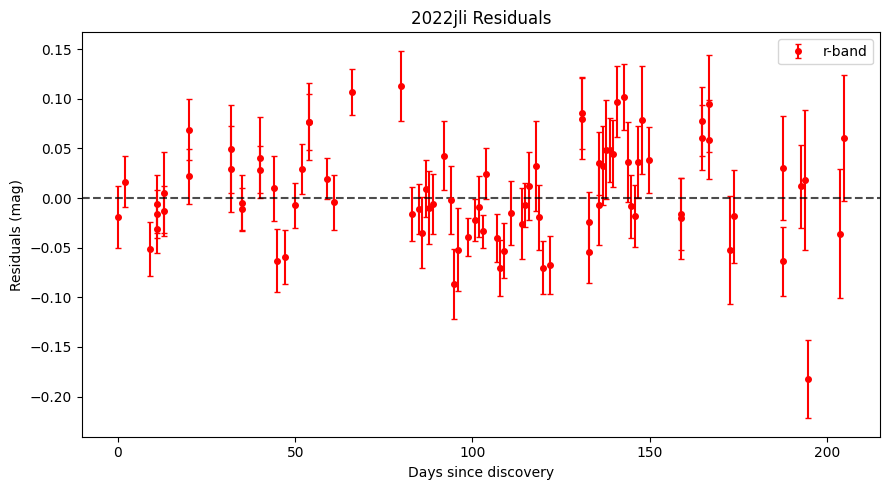

In [58]:
''' plot 2022jli resids'''
import numpy as np
import matplotlib.pyplot as plt

sn_name = "2022jli"
trial_period = 12.4

plt.figure(figsize=(9, 5))

all_residuals = []
all_times = []

for data in grouped_results["poly3"][sn_name][1:]:
    fid = data['fid']
    cand = next(e for e in candidate_library if e["name"] == sn_name and e["fid"] == fid)

    t = np.array(cand["days"])
    mag = np.array(cand['mags'])
    mag_err = np.array(cand['errs'])
    model = data['poly_model']

    residuals = mag - model(t)

    all_residuals.extend(residuals)
    all_times.extend(t)

    plt.errorbar(
        t,
        residuals,
        yerr=mag_err,
        fmt='o',
        color='green' if fid == 1 else 'red',
        markersize=4,
        capsize=2,
        label=f"{'g-band' if fid == 1 else 'r-band'}"
    )

all_residuals = np.array(all_residuals)
all_times = np.array(all_times)

sigma_res = np.std(all_residuals, ddof=1)
N = len(all_residuals)
mda = sigma_res / np.sqrt(N)

# Smooth sinusoid with amplitude = MDA
tt = np.linspace(all_times.min(), all_times.max(), 1000)
demo_signal = mda * np.sin(2 * np.pi * tt / trial_period)

# plt.plot(tt, demo_signal, linewidth=2,
#          label=f"Sinusoid with A = MDA = {mda:.4f} mag")

plt.axhline(0, linestyle='--', color='black', alpha=0.7)

plt.xlabel("Days since discovery")
plt.ylabel("Residuals (mag)")
plt.title("2022jli Residuals")
plt.legend()
plt.tight_layout()
plt.show()

### Plot chi2 vs freq

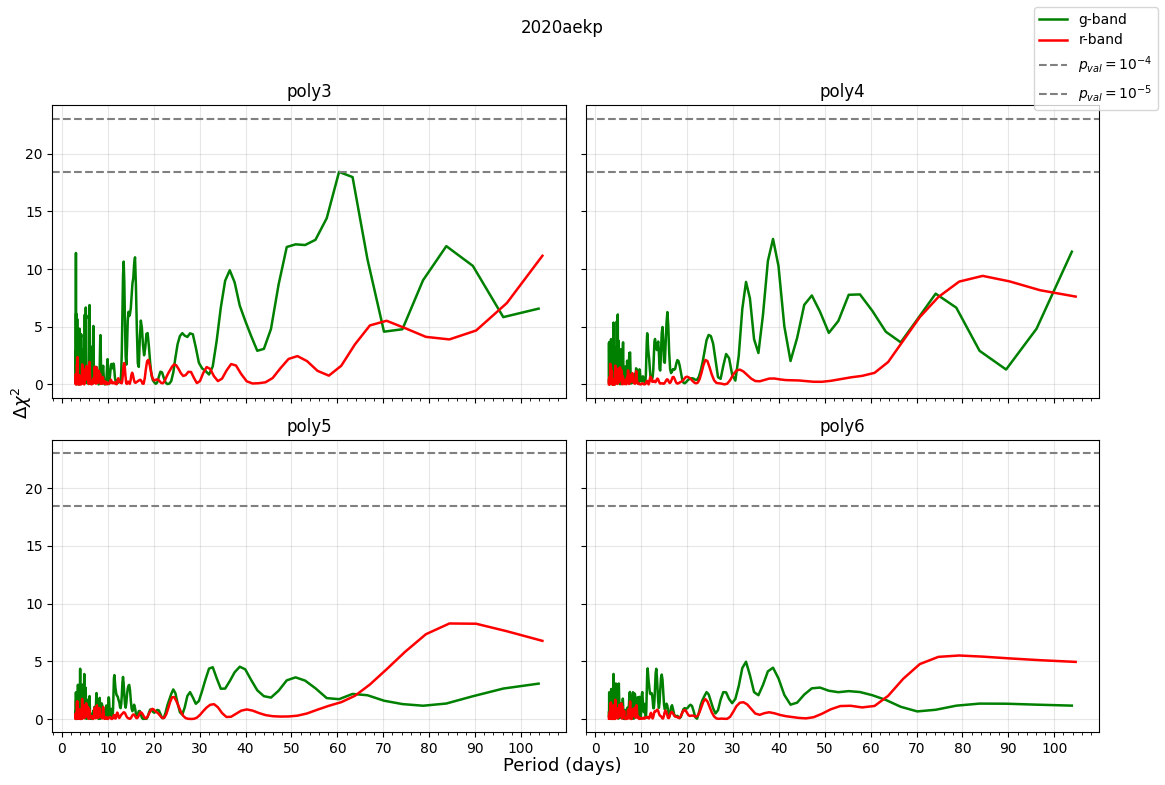

In [17]:
''' plot 4 subplots for all poly methods'''
import matplotlib.pyplot as plt

methods = ["poly3", "poly4", "poly5", "poly6"]
poly_degs = [3, 4, 5, 6]

sn_name = "2020aekp"

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, method, deg in zip(axes, methods, poly_degs):

    # Select both bands from candidate_library
    entries = [
        e for e in candidate_library
        if e["name"] == sn_name
    ]

    for entry in entries:

        fid = entry["fid"]
        days = entry["days"]
        mags = entry["mags"]
        errs = entry["errs"]

        freq, dchi2 = compute_delta_chi2_curve(
            days,
            mags,
            errs,
            poly_deg=deg
        )
        period = 1 / freq        
        color = "green" if fid == 1 else "red"
        label = "g-band" if fid == 1 else "r-band"
        ax.plot(period, dchi2, color=color, lw=1.8,
                label=label)       
    ax.axhline(chi2.ppf(1 - 1e-4, df=2), color='grey', ls='--', lw=1.5, label=r'$p_{val}=10^{-4}$')
    ax.axhline(chi2.ppf(1 - 1e-5, df=2), color='grey', ls='--', lw=1.5, label=r'$p_{val}=10^{-5}$')
    ax.set_title(method)
    ax.grid(alpha=0.3)

    # Dense ticks
    from matplotlib.ticker import MultipleLocator, AutoMinorLocator
    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))


# Axis labels
# fig.text(0.5, 0.04, "Frequency (1/days)", ha='center', fontsize=13)
fig.text(0.5, 0.04, "Period (days)", ha='center', fontsize=13)
fig.text(0.04, 0.5, r"$\Delta \chi^2$", va='center',
         rotation='vertical', fontsize=13)

# Single legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels)
fig.suptitle(sn_name)
plt.tight_layout(rect=[0.04, 0.04, 0.96, 0.96])
# plt.savefig('Figures/2019tsf_periodogram.pdf', dpi=300, bbox_inches='tight')
plt.show()

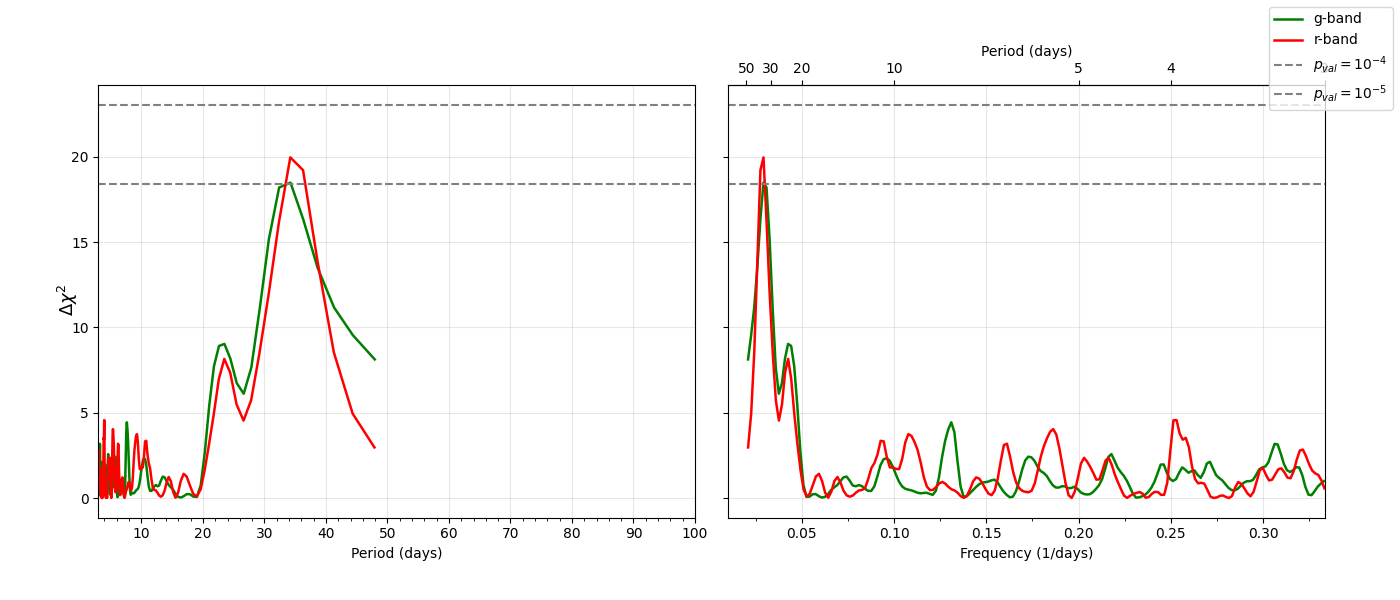

In [103]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

sn_name = "2022esa"

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

ax_period = axes[0]
ax_freq = axes[1]

entries = [
    e for e in candidate_library
    if e["name"] == sn_name
]

for entry in entries:

    fid = entry["fid"]
    days = entry["days"]
    mags = entry["mags"]
    errs = entry["errs"]

    freq, dchi2 = compute_delta_chi2_curve(
        days,
        mags,
        errs,
        poly_deg=3
    )

    period = 1 / freq

    color = "green" if fid == 1 else "red"
    label = "g-band" if fid == 1 else "r-band"
    ax_period.plot(period, dchi2, color=color, lw=1.8, label=label)
    ax_freq.plot(freq, dchi2, color=color, lw=1.8, label=label)

for ax in axes:
    ax.axhline(chi2.ppf(1 - 1e-4, df=2), color='grey', ls='--', lw=1.5, label=r'$p_{val}=10^{-4}$')
    ax.axhline(chi2.ppf(1 - 1e-5, df=2), color='grey', ls='--', lw=1.5, label=r'$p_{val}=10^{-5}$')
    ax.grid(alpha=0.3)

ax_period.set_xlabel("Period (days)")
ax_period.set_xlim(3, 100)
ax_period.xaxis.set_major_locator(MultipleLocator(10))
ax_period.xaxis.set_minor_locator(AutoMinorLocator(5))

ax_freq.set_xlabel("Frequency (1/days)")
ax_freq.set_xlim(1/100, 1/3)
ax_freq.xaxis.set_major_locator(MultipleLocator(0.05))
ax_freq.xaxis.set_minor_locator(AutoMinorLocator(2))

def one_over(x):
    x = np.asarray(x)
    return np.divide(1.0, x,
                     out=np.full_like(x, np.nan, dtype=float),
                     where=x != 0)

secax = ax_freq.secondary_xaxis('top', functions=(one_over, one_over))
period_ticks = np.array([3, 4, 5, 10, 20, 30, 50])
secax.set_xticks(period_ticks)
secax.set_xticklabels(period_ticks)
secax.set_xlabel("Period (days)")

fig.text(0.04, 0.5, r"$\Delta \chi^2$", va='center',
         rotation='vertical', fontsize=13)

handles, labels = ax_freq.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

# fig.suptitle(sn_name)
plt.tight_layout(rect=[0.04, 0.04, 0.96, 0.95])
# plt.savefig('Figures/2020sgf_periodogram_freq.pdf', dpi=300, bbox_inches='tight')
plt.show()

g-band: f = 0.033147 [0.032808, 0.034558] 1/day, P = 30.169 [28.937, 30.481] days
r-band: f = 0.027822 [0.026381, 0.029059] 1/day, P = 35.942 [34.413, 37.907] days


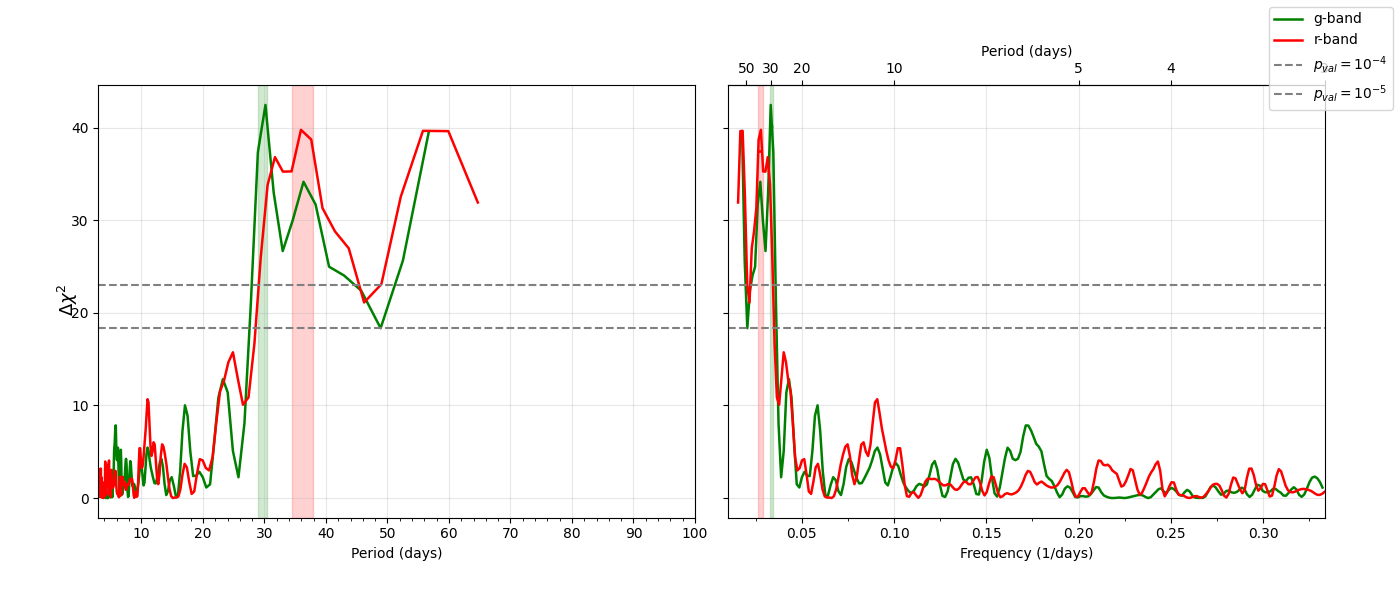

In [104]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

from periodicity_tools import find_peak_ci_from_dchi2

sn_name = "2020sgf"

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

ax_period = axes[0]
ax_freq = axes[1]

entries = [
    e for e in candidate_library
    if e["name"] == sn_name
]

for entry in entries:

    fid = entry["fid"]
    days = entry["days"]
    mags = entry["mags"]
    errs = entry["errs"]

    freq, dchi2 = compute_delta_chi2_curve(
        days,
        mags,
        errs,
        poly_deg=3
    )

    period = 1 / freq

    color = "green" if fid == 1 else "red"
    label = "g-band" if fid == 1 else "r-band"

    ax_period.plot(period, dchi2, color=color, lw=1.8, label=label)
    ax_freq.plot(freq, dchi2, color=color, lw=1.8, label=label)

    # confidence interval in frequency space
    f_peak, f_lo, f_hi, ci_level = find_peak_ci_from_dchi2(
        freq,
        dchi2,
        conf=0.68,
        df=2
    )

    # translate CI to period space
    p_peak = 1 / f_peak
    p_lo = 1 / f_hi if np.isfinite(f_hi) else np.nan
    p_hi = 1 / f_lo if np.isfinite(f_lo) else np.nan

    print(
        f"{label}: "
        f"f = {f_peak:.6f} [{f_lo:.6f}, {f_hi:.6f}] 1/day, "
        f"P = {p_peak:.3f} [{p_lo:.3f}, {p_hi:.3f}] days"
    )

    if np.isfinite(f_lo) and np.isfinite(f_hi):

        # horizontal confidence line on frequency plot
        ax_freq.hlines(
            ci_level,
            f_lo,
            f_hi,
            color=color,
            ls=":",
            lw=2
        )

        # shade frequency confidence interval
        ax_freq.axvspan(
            f_lo,
            f_hi,
            color=color,
            alpha=0.18
        )

        # shade corresponding period confidence interval
        ax_period.axvspan(
            p_lo,
            p_hi,
            color=color,
            alpha=0.18
        )

for ax in axes:
    ax.axhline(
        chi2.ppf(1 - 1e-4, df=2),
        color='grey',
        ls='--',
        lw=1.5,
        label=r'$p_{val}=10^{-4}$'
    )

    ax.axhline(
        chi2.ppf(1 - 1e-5, df=2),
        color='grey',
        ls='--',
        lw=1.5,
        label=r'$p_{val}=10^{-5}$'
    )

    ax.grid(alpha=0.3)

ax_period.set_xlabel("Period (days)")
ax_period.set_xlim(3, 100)
ax_period.xaxis.set_major_locator(MultipleLocator(10))
ax_period.xaxis.set_minor_locator(AutoMinorLocator(5))

ax_freq.set_xlabel("Frequency (1/days)")
ax_freq.set_xlim(1/100, 1/3)
ax_freq.xaxis.set_major_locator(MultipleLocator(0.05))
ax_freq.xaxis.set_minor_locator(AutoMinorLocator(2))

def one_over(x):
    x = np.asarray(x)

    return np.divide(
        1.0,
        x,
        out=np.full_like(x, np.nan, dtype=float),
        where=x != 0
    )

secax = ax_freq.secondary_xaxis(
    'top',
    functions=(one_over, one_over)
)

period_ticks = np.array([3, 4, 5, 10, 20, 30, 50])

secax.set_xticks(period_ticks)
secax.set_xticklabels(period_ticks)
secax.set_xlabel("Period (days)")

fig.text(
    0.04,
    0.5,
    r"$\Delta \chi^2$",
    va='center',
    rotation='vertical',
    fontsize=13
)

handles, labels = ax_freq.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout(rect=[0.04, 0.04, 0.96, 0.95])
# plt.savefig('Figures/2020sgf_periodogram.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
''' calc period tolerance for 2020sgf'''
P1 = grouped_results["poly3"]["2020sgf"][0]['best_period']
T1 = grouped_results["poly3"]["2020sgf"][0]['time_baseline']
P2 = grouped_results["poly3"]["2020sgf"][1]['best_period']
T2 = grouped_results["poly3"]["2020sgf"][1]['time_baseline']

print("P1^2/T1", P1**2/T1)
print("P2^2/T2", P2**2/T2)
grouped_results["poly3"]["2020sgf"][0]['time_baseline']

P1^2/T1 6.41884263467858
P2^2/T2 7.987175353101369


np.float64(161.74030090030283)

In [12]:
''' find mean MDA'''
mda_values = []

for name, band_results in grouped_results["poly3"].items():
    if name not in dual_band_sne:
        continue
    for res in band_results:
        mda_values.append(res["mda"])
mean_mda = np.mean(mda_values)
percentiles = np.percentile(mda_values, [25, 50, 75])
print(f"Mean MDA across dual-band candidates (poly3): {mean_mda:.3f} mag")
print(f"25th, 50th, 75th percentiles: {percentiles}")

Mean MDA across dual-band candidates (poly3): 0.016 mag
25th, 50th, 75th percentiles: [0.01074637 0.01604926 0.02145646]


### Plot fraction of periodic SNe

In [105]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.stats import binom_conf_interval

TWO_SIGMA = 0.9545

period_thresholds = [10, 20, 30, 40, 50, 60]

double_hits, updated_grouped = find_dual_band_hits(grouped_results, candidate_library)
double_hits = double_hits['poly3']

sn_baselines = {}

for entry in candidate_library:
    name = entry["name"]

    if name not in dual_band_sne:
        continue

    days = np.asarray(entry["days"])
    T = days.max() - days.min()

    # Keep shortest baseline per SN, since that's the limiting factor
    if name not in sn_baselines:
        sn_baselines[name] = T
    else:
        sn_baselines[name] = min(sn_baselines[name], T)

sn_detected_periods = {}

for sn in double_hits:
    band_results = updated_grouped['poly3'][sn]

    best_p1 = band_results[0]['best_period']
    best_p2 = band_results[1]['best_period']

    # Conservative choice: require both bands to be below threshold
    sn_detected_periods[sn] = max(best_p1, best_p2)


fractions = []
lower_bounds = []
upper_bounds = []
valid_counts = []
hit_counts = []

fracs_jli = []
lower_bounds_jli = []
upper_bounds_jli = []

for P in period_thresholds:

    searchable_sne = {
        name for name, T in sn_baselines.items()
        if T > 2.5 * P
    }

    Y = len(searchable_sne)

    detected_sne = {
        sn for sn, Pdet in sn_detected_periods.items()
        if sn in searchable_sne and Pdet < P
    }

    X = len(detected_sne)

    frac = X / Y if Y > 0 else np.nan

    lo, hi = binom_conf_interval(
        X, Y,
        confidence_level=TWO_SIGMA,
        interval='wilson'
    )

    fractions.append(frac)
    lower_bounds.append(lo)
    upper_bounds.append(hi)
    valid_counts.append(Y)
    hit_counts.append(X)

    # 2022jli comparison curve
    X_jli = int(P > 12.4)
    frac_jli = X_jli / Y if Y > 0 else np.nan

    lo_jli, hi_jli = binom_conf_interval(
        X_jli, Y,
        confidence_level=TWO_SIGMA,
        interval='wilson'
    )

    fracs_jli.append(frac_jli)
    lower_bounds_jli.append(lo_jli)
    upper_bounds_jli.append(hi_jli)

    print(
        f"P < {P:>2} days "
        f"(T > {2.5 * P:.1f}): "
        f"X = {X}, Y = {Y}, Fraction = {frac:.3f}"
    )


plt.figure(figsize=(7, 5))

plt.step(
    period_thresholds,
    fractions,
    where='pre',
    color='black',
    linewidth=3,
    label='Cumulative periodic fraction'
)

plt.scatter(
    period_thresholds,
    fractions,
    color='black',
    zorder=3
)

plt.fill_between(
    period_thresholds,
    lower_bounds,
    upper_bounds,
    step='pre',
    color='blue',
    alpha=0.2,
    label=r'2$\sigma$ binomial confidence'
)

plt.step(
    period_thresholds,
    fracs_jli,
    where='pre',
    color='red',
    linewidth=2,
    label='Only SN 2022jli'
)

plt.scatter(
    period_thresholds,
    fracs_jli,
    color='red',
    zorder=3
)

plt.step(
    period_thresholds,
    upper_bounds_jli,
    where='pre',
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=r'2$\sigma$ confidence: only SN 2022jli'
)

plt.step(
    period_thresholds,
    lower_bounds_jli,
    where='pre',
    color='red',
    linestyle='--',
    linewidth=1.5
)

plt.xlabel("Maximum Period $P$ (days)")
plt.ylabel("Fraction of Periodic SNe with Period $<P$")
plt.ylim(0, 0.7)
plt.yticks(np.arange(0, 0.71, 0.05))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# plt.savefig('Figures/frac_limit.pdf', dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'dual_band_sne' is not defined

Pdet >  5 days (T > 12.5): X = 3, Y = 34, Fraction = 0.088
Pdet > 10 days (T > 25.0): X = 3, Y = 33, Fraction = 0.091
Pdet > 15 days (T > 37.5): X = 2, Y = 32, Fraction = 0.062
Pdet > 20 days (T > 50.0): X = 2, Y = 30, Fraction = 0.067
Pdet > 25 days (T > 62.5): X = 2, Y = 27, Fraction = 0.074
Pdet > 30 days (T > 75.0): X = 2, Y = 26, Fraction = 0.077
Pdet > 35 days (T > 87.5): X = 0, Y = 23, Fraction = 0.000
Pdet > 40 days (T > 100.0): X = 0, Y = 19, Fraction = 0.000


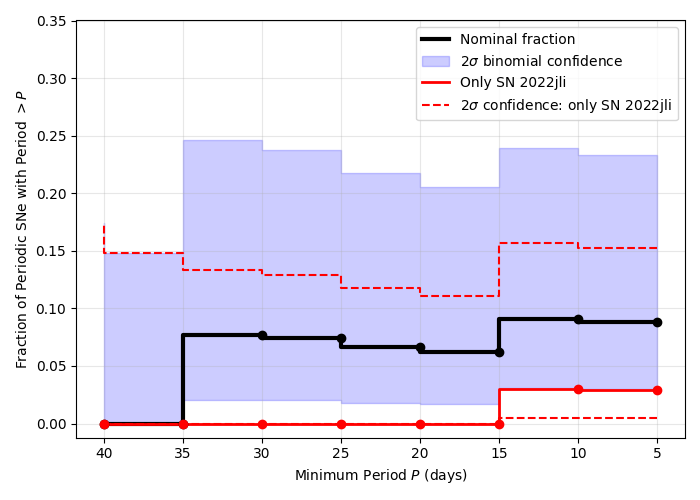

In [127]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.stats import binom_conf_interval

TWO_SIGMA = 0.9545

period_thresholds = np.array([5, 10, 15, 20, 25, 30, 35, 40])

double_hits, updated_grouped = find_dual_band_hits(grouped_results, candidate_library)
double_hits = double_hits['poly3']

sn_baselines = {}

bands_per_sn = defaultdict(set)
for entry in candidate_library:
    bands_per_sn[entry["name"]].add(entry["fid"])
dual_band_sne = {
    name for name, bands in bands_per_sn.items()
    if {1, 2}.issubset(bands)
}


for entry in candidate_library:
    name = entry["name"]

    if name not in dual_band_sne:
        continue

    days = np.asarray(entry["days"])
    T = days.max() - days.min()

    # Keep shortest baseline per SN, since that is the limiting factor
    if name not in sn_baselines:
        sn_baselines[name] = T
    else:
        sn_baselines[name] = min(sn_baselines[name], T)

sn_detected_periods = {}

for sn in double_hits:
    band_results = grouped_results['poly3'][sn]

    best_p1 = band_results[0]['best_period']
    best_p2 = band_results[1]['best_period']

    # Conservative choice: both bands must exceed threshold
    sn_detected_periods[sn] = min(best_p1, best_p2)

fractions = []
lower_bounds = []
upper_bounds = []
valid_counts = []
hit_counts = []

fracs_jli = []
lower_bounds_jli = []
upper_bounds_jli = []

for P in period_thresholds:

    # Denominator:
    # SNe with enough baseline to detect period P.
    # As P decreases, this denominator grows.
    valid_sne = {
        name for name, T in sn_baselines.items()
        if T > 2.5 * P
    }

    Y = len(valid_sne)

    # Numerator:
    # unique detected SNe with detected period larger than P,
    # restricted to the same baseline-complete sample.
    detected_sne = {
        sn for sn, Pdet in sn_detected_periods.items()
        if sn in valid_sne and Pdet > P
    }

    X = len(detected_sne)

    frac = X / Y if Y > 0 else np.nan

    lo, hi = binom_conf_interval(
        X, Y,
        confidence_level=TWO_SIGMA,
        interval='wilson'
    )

    fractions.append(frac)
    lower_bounds.append(lo)
    upper_bounds.append(hi)
    valid_counts.append(Y)
    hit_counts.append(X)

    # SN 2022jli comparison:
    # It contributes when its period is greater than the threshold P.
    X_jli = int(12.4 > P)
    frac_jli = X_jli / Y if Y > 0 else np.nan

    lo_jli, hi_jli = binom_conf_interval(
        X_jli, Y,
        confidence_level=TWO_SIGMA,
        interval='wilson'
    )

    fracs_jli.append(frac_jli)
    lower_bounds_jli.append(lo_jli)
    upper_bounds_jli.append(hi_jli)

    print(
        f"Pdet > {P:>2} days "
        f"(T > {2.5 * P:.1f}): "
        f"X = {X}, Y = {Y}, Fraction = {frac:.3f}"
    )

plt.figure(figsize=(7, 5))

plt.step(
    period_thresholds,
    fractions,
    where='post',
    color='black',
    linewidth=3,
    label='Nominal fraction'
)

plt.scatter(
    period_thresholds,
    fractions,
    color='black',
    zorder=3
)

plt.fill_between(
    period_thresholds,
    lower_bounds,
    upper_bounds,
    step='post',
    color='blue',
    alpha=0.2,
    label=r'2$\sigma$ binomial confidence'
)

plt.step(
    period_thresholds,
    fracs_jli,
    where='post',
    color='red',
    linewidth=2,
    label='Only SN 2022jli'
)

plt.scatter(
    period_thresholds,
    fracs_jli,
    color='red',
    zorder=3
)

plt.step(
    period_thresholds,
    upper_bounds_jli,
    where='post',
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=r'2$\sigma$ confidence: only SN 2022jli'
)

plt.step(
    period_thresholds,
    lower_bounds_jli,
    where='post',
    color='red',
    linestyle='--',
    linewidth=1.5
)

plt.xlabel("Minimum Period $P$ (days)")
plt.ylabel("Fraction of Periodic SNe with Period $>P$")

plt.gca().invert_xaxis()

# plt.ylim(0, 0.4)
plt.yticks(np.arange(0, 0.36, 0.05))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# plt.savefig('Figures/frac_limit_Pmin.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [121]:
upper_bounds

[np.float64(0.2332997472727948),
 np.float64(0.2394929115503895),
 np.float64(0.2053103738194699),
 np.float64(0.21724279524986057),
 np.float64(0.237983661390943),
 np.float64(0.24580392085606864),
 np.float64(0.14814845656902542)]

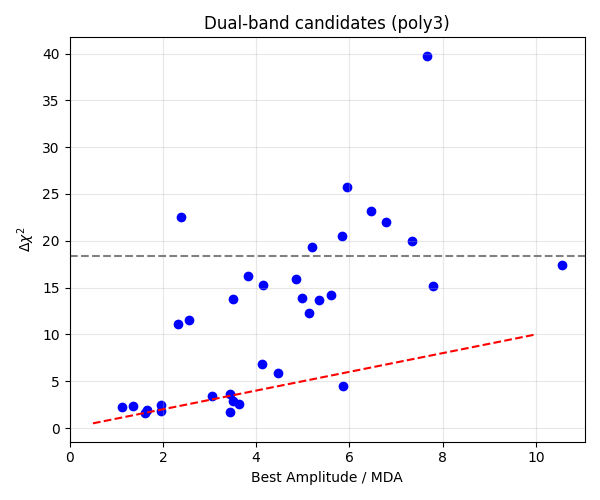

In [133]:
from scipy.stats import chi2

ratios = []
for name in dual_band_sne:
    sgf = grouped_results['poly3'][name]
    mda = max(sgf[1]['mda'], 0.015)
    ratios.append((sgf[1]['best_amplitude']/ mda, sgf[1]['delta_chi2']))

ratios = np.array(ratios)
plt.figure(figsize=(6, 5))
plt.scatter(ratios[:, 0], ratios[:, 1], color='blue')
plt.xlabel("Best Amplitude / MDA")
# plt.axhline(np.sqrt(chi2.ppf(1 - 1e-4, df=2)), color='grey', ls='--', lw=1.5, label=r'$\sqrt{\Delta \chi^2}$ threshold for $p_{val}=10^{-4}$')
plt.axhline(chi2.ppf(1 - 1e-4, df=2), color='grey', ls='--', lw=1.5, label=r'$\sqrt{\Delta \chi^2}$ threshold for $p_{val}=10^{-4}$')
plt.ylabel(r"$ \Delta \chi^2$")
plt.title("Dual-band candidates (poly3)")
plt.grid(alpha=0.3)
xs = np.linspace(0.5, 10, 100)
plt.plot(xs, xs, color='red', ls='--', label="Amplitude = MDA")    
plt.tight_layout()
# plt.savefig('Figures/dual_band_ratios.pdf', dpi=300, bbox_inches='tight')
plt.show()

### Injection Simulation
instead of fig 5, show a table of P, A, detections, sensitivity (how many could have been detected with injections)


Detected rounded P/A values used for the table grid:
Running 4 x 10 = 40 rows
Dual-band candidate-library sample: 34 candidates


Recovery table rows:   0%|          | 0/40 [00:00<?, ?it/s]

[1/40] P>10.0, A=[0.01, 0.03): 33 eligible candidates


candidates:   0%|          | 0/33 [00:00<?, ?it/s]

[1/40] done: detections=0, candidates=33, recovery=0.90 (9/330 trials recovered)
[2/40] P>10.0, A=[0.03, 0.05): 33 eligible candidates


...

[38/40] done: detections=0, candidates=19, recovery=10.00 (100/190 trials recovered)
[39/40] P>40.0, A=[0.17, 0.19): 19 eligible candidates


candidates:   0%|          | 0/19 [00:00<?, ?it/s]

[39/40] done: detections=0, candidates=19, recovery=11.30 (113/190 trials recovered)
[40/40] P>40.0, A=[0.19, 0.21): 19 eligible candidates


candidates:   0%|          | 0/19 [00:00<?, ?it/s]

[40/40] done: detections=0, candidates=19, recovery=12.20 (122/190 trials recovered)
Saved sensitivity_table.csv, sensitivity_diagnostics.csv, and recovery_colormap.csv


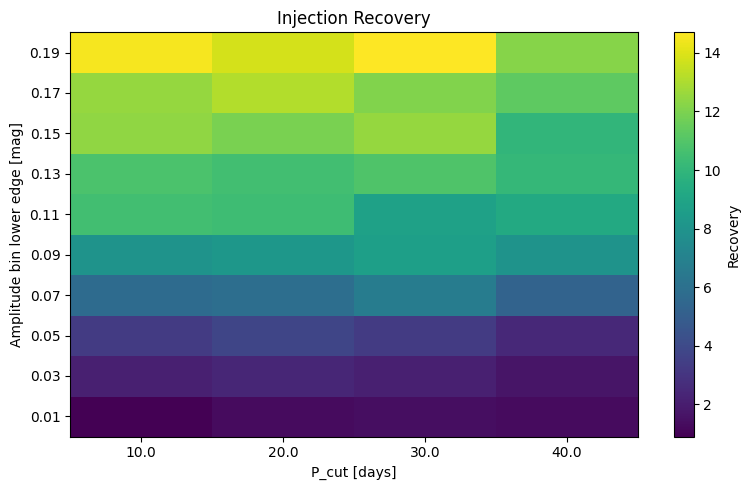

,Period,Amplitude,Detections,Candidates,Recovery
0,10,0.01,0,33,0.9
1,10,0.03,1,33,2.1
2,10,0.05,0,33,3.3
3,10,0.07,0,33,5.7
4,10,0.09,0,33,8.0
5,10,0.11,2,33,10.5
6,10,0.13,0,33,10.8
7,10,0.15,0,33,12.4
8,10,0.17,0,33,12.5
9,10,0.19,0,33,14.5


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.stats import chi2
from tqdm.auto import tqdm
from periodicity_tools import analyze_candidate, compute_delta_chi2_curve

N_INJECTIONS = 10
RNG_SEED = 12345
SHOW_INNER_TQDM = False
SINGLE_FREQ_P = 1e-4
SIG_THRESHOLD = chi2.ppf(1 - SINGLE_FREQ_P, df=2)
AMP_BIN_WIDTH = 0.02
AMP_GRID_START = 0.01
AMP_GRID_MIN_MAX = 0.20

double_hits_all, updated_grouped_all = find_dual_band_hits(grouped_results, candidate_library)
updated_results = updated_grouped_all["poly3"]
poly3_results = grouped_results["poly3"]

# One conservative rounded P/A pair per detection: both bands must pass a threshold.
detected_rows = []
for name, band_results in updated_results.items():
    if len(band_results) < 2:
        continue
    detected_rows.append({
        "Name": name,
        "Period": round(min(r["best_period"] for r in band_results), 1),
        "Amplitude": round(min(r["best_amplitude"] for r in band_results), 2),
    })

max_detected_amp = max(r["best_amplitude"] for band_results in updated_results.values() for r in band_results)
max_amp = max(AMP_GRID_MIN_MAX, max_detected_amp)
amplitude_grid = np.round(np.arange(AMP_GRID_START, max_amp + 1e-9, AMP_BIN_WIDTH), 2)
period_grid = np.arange(10, 41, 10)

print("Detected rounded P/A values used for the table grid:")
print(f"Running {len(period_grid)} x {len(amplitude_grid)} = {len(period_grid) * len(amplitude_grid)} rows")

# Survey sample: candidates from candidate_library with both g and r bands.
entries_by_name = defaultdict(dict)
for entry in candidate_library:
    if entry["fid"] in (1, 2):
        entries_by_name[entry["name"]][entry["fid"]] = entry

dual_band_names = sorted(
    name for name, bands in entries_by_name.items()
    if 1 in bands and 2 in bands and name in poly3_results
)
print(f"Dual-band candidate-library sample: {len(dual_band_names)} candidates")

# Convenience lookup for the poly3 survey results, where time_baseline lives.
poly3_by_name_fid = defaultdict(dict)
for name, band_results in poly3_results.items():
    for res in band_results:
        poly3_by_name_fid[name][res["fid"]] = res


def has_peak_near_period(entry, target_period, period_tol):
    freq, dchi2 = compute_delta_chi2_curve(
        entry["days"],
        entry["mags"],
        entry["errs"],
        poly_deg=3,
    )
    periods = 1.0 / freq
    mask = np.abs(periods - target_period) < period_tol
    if not np.any(mask):
        return False

    local_dchi2 = dchi2[mask]
    if len(local_dchi2) < 3:
        return np.nanmax(local_dchi2) > SIG_THRESHOLD

    local_max = (
        (local_dchi2[1:-1] > local_dchi2[:-2]) &
        (local_dchi2[1:-1] > local_dchi2[2:])
    )
    if not np.any(local_max):
        return np.nanmax(local_dchi2) > SIG_THRESHOLD

    return np.any(local_dchi2[1:-1][local_max] > SIG_THRESHOLD)


def recovered_in_both_bands(sim_entries, injected_period):
    results = []
    for entry in sim_entries:
        res = analyze_candidate(
            entry["name"],
            entry["days"],
            entry["mags"],
            entry["errs"],
            poly_deg=3,
        )
        res["fid"] = entry["fid"]
        results.append(res)

    r1, r2 = results
    if not (
        r1["p_value_single_freq"] < SINGLE_FREQ_P and
        r2["p_value_single_freq"] < SINGLE_FREQ_P and
        r1["best_amplitude"] >= r1["mda"] and
        r2["best_amplitude"] >= r2["mda"]
    ):
        return False

    period_tol = max(
        r1["best_period"] ** 2 / r1["time_baseline"],
        r2["best_period"] ** 2 / r2["time_baseline"],
    )

    if not (
        abs(r1["best_period"] - injected_period) < period_tol or
        abs(r2["best_period"] - injected_period) < period_tol
    ):
        return False

    return all(has_peak_near_period(entry, injected_period, period_tol) for entry in sim_entries)


def make_injected_light_curve(entry, period, amplitude, rng):
    days = np.asarray(entry["days"])
    mags = np.asarray(entry["mags"])

    phase = rng.uniform(0.0, 2.0 * np.pi)
    signal = amplitude * np.sin(2.0 * np.pi * days / period + phase)

    sim_entry = entry.copy()
    sim_entry["mags"] = mags + signal
    return sim_entry


rng = np.random.default_rng(RNG_SEED)
rows = []
diagnostics_rows = []
row_grid = [(P, A) for P in period_grid for A in amplitude_grid]
detected_pa = pd.DataFrame(detected_rows).sort_values("Period").reset_index(drop=True)

for row_i, (P_cut, A_cut) in enumerate(tqdm(row_grid, desc="Recovery table rows", dynamic_ncols=True), start=1):
    A_hi = round(A_cut + AMP_BIN_WIDTH, 2)

    # Period is cumulative; amplitude is binned.
    detected_count = int((
        (detected_pa["Period"] > P_cut) &
        (detected_pa["Amplitude"] >= A_cut) &
        (detected_pa["Amplitude"] < A_hi)
    ).sum())

    eligible_names = []
    for name in dual_band_names:
        p_max = min(
            poly3_by_name_fid[name][1]["time_baseline"],
            poly3_by_name_fid[name][2]["time_baseline"],
        ) / 2.5
        if p_max > P_cut:
            eligible_names.append((name, p_max))

    tqdm.write(
        f"[{row_i}/{len(row_grid)}] P>{P_cut:.1f}, "
        f"A=[{A_cut:.2f}, {A_hi:.2f}): {len(eligible_names)} eligible candidates"
    )

    recovery_rates = []
    recovered_total = 0
    trials_total = 0

    for name, p_max in tqdm(eligible_names, desc="candidates", leave=False, position=1, dynamic_ncols=True):
        recovered = 0
        injection_iter = tqdm(
            range(N_INJECTIONS),
            desc=name,
            leave=False,
            position=2,
            dynamic_ncols=True,
            disable=not SHOW_INNER_TQDM,
        )

        for _ in injection_iter:
            injected_period = rng.uniform(P_cut, p_max)
            injected_amplitude = rng.uniform(A_cut, A_hi)
            sim_entries = [
                make_injected_light_curve(entries_by_name[name][fid], injected_period, injected_amplitude, rng)
                for fid in (1, 2)
            ]
            recovered += int(recovered_in_both_bands(sim_entries, injected_period))

        recovery_rates.append(recovered / N_INJECTIONS)
        recovered_total += recovered
        trials_total += N_INJECTIONS

    recovery = float(np.sum(recovery_rates))

    rows.append({
        "Period": P_cut,
        "Amplitude": A_cut,
        "Detections": detected_count,
        "Candidates": len(eligible_names),
        "Recovery": recovery,
    })
    diagnostics_rows.append({
        "Period": P_cut,
        "Amplitude": A_cut,
        "AmplitudeHigh": A_hi,
        "EligibleCandidates": len(eligible_names),
        "RecoveredTrials": recovered_total,
        "InjectionTrials": trials_total,
        "MeanRecoveryRate": recovered_total / trials_total if trials_total else np.nan,
    })

    tqdm.write(
        f"[{row_i}/{len(row_grid)}] done: "
        f"detections={detected_count}, candidates={len(eligible_names)}, recovery={recovery:.2f} "
        f"({recovered_total}/{trials_total} trials recovered)"
    )

sensitivity_table = pd.DataFrame(rows)
sensitivity_diagnostics = pd.DataFrame(diagnostics_rows)

recovery_map = sensitivity_table.pivot(index="Amplitude", columns="Period", values="Recovery").sort_index()

sensitivity_table.to_csv("sensitivity_table.csv", index=False)
sensitivity_diagnostics.to_csv("sensitivity_diagnostics.csv", index=False)
recovery_map.to_csv("recovery_colormap.csv")
print("Saved sensitivity_table.csv, sensitivity_diagnostics.csv, and recovery_colormap.csv")

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(recovery_map.values, origin="lower", aspect="auto", cmap="viridis")
ax.set_xticks(np.arange(len(recovery_map.columns)))
ax.set_xticklabels([f"{p:.1f}" for p in recovery_map.columns])
ax.set_yticks(np.arange(len(recovery_map.index)))
ax.set_yticklabels([f"{a:.2f}" for a in recovery_map.index])
ax.set_xlabel("P_cut [days]")
ax.set_ylabel("Amplitude bin lower edge [mag]")
ax.set_title("Injection Recovery")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Recovery")
plt.tight_layout()
plt.show()

sensitivity_table


In [ ]:
''' plot recovery colormap from saved CSV'''
sensitivity_table = pd.read_csv("sensitivity_table.csv")
sensitivity_diagnostics = pd.read_csv("sensitivity_diagnostics.csv")
recovery_map = pd.read_csv("recovery_colormap.csv", index_col=0)

recovery_map.columns = recovery_map.columns.astype(float)
recovery_map.index = recovery_map.index.astype(float)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(recovery_map.values, origin="lower", aspect="auto", cmap="viridis")
ax.set_xticks(np.arange(len(recovery_map.columns)))
ax.set_xticklabels([f"{p:.1f}" for p in recovery_map.columns])
ax.set_yticks(np.arange(len(recovery_map.index)))
ax.set_yticklabels([f"{a:.2f}" for a in recovery_map.index])
ax.set_xlabel("P_cut [days]")
ax.set_ylabel("Amplitude bin lower edge [mag]")
ax.set_title("Injection Recovery")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Recovery")
plt.tight_layout()
plt.show()

sensitivity_table

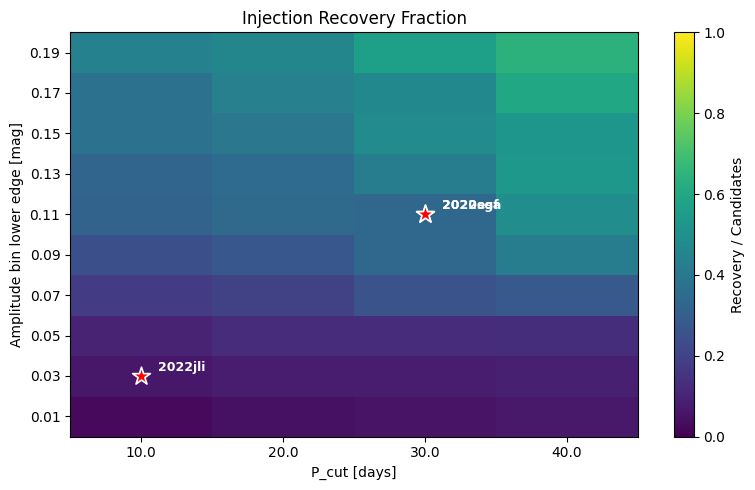

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Build the same map
recovery_fraction_map = (
    sensitivity_table
    .pivot(index="Amplitude", columns="Period", values="RecoveryFraction")
    .sort_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(
    recovery_fraction_map.values,
    origin="lower",
    aspect="auto",
    cmap="viridis",
    vmin=0,
    vmax=1,
)

ax.set_xticks(np.arange(len(recovery_fraction_map.columns)))
ax.set_xticklabels([f"{p:.1f}" for p in recovery_fraction_map.columns])

ax.set_yticks(np.arange(len(recovery_fraction_map.index)))
ax.set_yticklabels([f"{a:.2f}" for a in recovery_fraction_map.index])

ax.set_xlabel("P_cut [days]")
ax.set_ylabel("Amplitude bin lower edge [mag]")
ax.set_title("Injection Recovery Fraction")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Recovery / Candidates")

# Overlay detected SNe
period_values = recovery_fraction_map.columns.to_numpy(dtype=float)
amplitude_values = recovery_fraction_map.index.to_numpy(dtype=float)

for _, row in detected_pa.iterrows():
    x = np.argmin(np.abs(period_values - row["Period"]))
    y = np.argmin(np.abs(amplitude_values - row["Amplitude"]))

    ax.scatter(
        x,
        y,
        marker="*",
        s=180,
        color="red",
        edgecolor="white",
        linewidth=1.2,
        zorder=5,
    )

    ax.text(
        x + 0.12,
        y + 0.12,
        row["Name"],
        color="white",
        fontsize=9,
        weight="bold",
        zorder=6,
    )

plt.tight_layout()
plt.show()

In [ ]:
grouped_results["poly3"]["2022jli"]

[{'name': '2022jli',
  'best_frequency': np.float64(0.07962565474834687),
  'best_period': np.float64(12.5587664322567),
  'period_lo': np.float64(12.242822622640178),
  'period_hi': np.float64(12.608901646234699),
  'best_amplitude': np.float64(0.06779241700230068),
  'mda': np.float64(0.0066274981690653285),
  'delta_chi2': np.float64(53.85079680469564),
  'chi2_poly': np.float64(91.00000000000026),
  'p_value_single_freq': np.float64(2.025157819218748e-12),
  'poly_degree': 3,
  'time_baseline': np.float64(194.66087969997898),
  'resids': array([-0.0021054 ,  0.0326063 ,  0.00357341, -0.02204136, -0.08191702,
         -0.05787865,  0.02261959,  0.05600293,  0.02091411,  0.06377523,
         -0.03047355, -0.03348443,  0.01495019,  0.04198745,  0.0943504 ,
          0.02076537, -0.08541657, -0.03680573, -0.01510128, -0.0193422 ,
         -0.0434129 , -0.14845351, -0.13860487, -0.03333759, -0.00181201,
          0.03929121,  0.04298161,  0.03426344,  0.03418716, -0.0250984 ,
         -

## Generating Tables

In [106]:
# Generate LaTeX format for Table 1 — poly3 only

double_hits, updated_grouped = find_dual_band_hits(grouped_results, candidate_library)
method = "poly3"

print(r"\begin{table*}")
print(r"\centering")
print(r"\begin{tabular}{lcccccc}")
print(r"\hline")
print(r"SN & $P_g$ & $A_g$ & $p_g$ & $P_r$ & $A_r$ & $p_r$ \\")
print(r"& [Days] & [mag] & & [Days] & [mag] & \\")
print(r"\hline")

def format_pval(pval):
    if pval > 0:
        exponent = int(np.floor(np.log10(pval)))
        mantissa = pval / 10**exponent
        return rf"${mantissa:.0f}\cdot 10^{{{exponent}}}$"
    else:
        return r"$<10^{-16}$"

def format_period(res):
    P = res["best_period"]
    lo = P-res["period_lo"]
    hi = res["period_hi"]-P
    return rf"${P:.1f}^{{+{hi:.1f}}}_{{-{lo:.1f}}}$"

for name in sorted(double_hits.get(method, [])):

    band_results = updated_grouped[method][name]

    g_res = next(r for r in band_results if r["fid"] == 1)
    r_res = next(r for r in band_results if r["fid"] == 2)

    pval_g = format_pval(g_res["p_value_single_freq"])
    pval_r = format_pval(r_res["p_value_single_freq"])

    Pg = format_period(g_res)
    Pr = format_period(r_res)

    print(f"{name} & "
          f"{Pg} & "
          f"{g_res['best_amplitude']:.2f} & "
          f"{pval_g} & "
          f"{Pr} & "
          f"{r_res['best_amplitude']:.2f} & "
          f"{pval_r} \\\\")
    
print(r"\hline")
print(r"\end{tabular}")
print(r"\caption{Dual-band periodic detections identified using a third-degree polynomial baseline. "
      r"Periods, amplitudes, and single-frequency $p$-values are listed for both bands.}")
print(r"\label{tab:double_hits_poly3}")
print(r"\end{table*}")

\begin{table*}
\centering
\begin{tabular}{lcccccc}
\hline
SN & $P_g$ & $A_g$ & $p_g$ & $P_r$ & $A_r$ & $p_r$ \\
& [Days] & [mag] & & [Days] & [mag] & \\
\hline
2020sgf & $30.2^{+0.3}_{-1.2}$ & 0.20 & $6\cdot 10^{-10}$ & $35.9^{+2.0}_{-1.5}$ & 0.12 & $2\cdot 10^{-9}$ \\
2022esa & $34.2^{+2.2}_{-3.5}$ & 0.14 & $10\cdot 10^{-5}$ & $34.2^{+2.7}_{-1.8}$ & 0.11 & $5\cdot 10^{-5}$ \\
2022jli & $12.6^{+0.1}_{-0.3}$ & 0.07 & $2\cdot 10^{-12}$ & $12.4^{+0.1}_{-0.3}$ & 0.04 & $1\cdot 10^{-5}$ \\
\hline
\end{tabular}
\caption{Dual-band periodic detections identified using a third-degree polynomial baseline. Periods, amplitudes, and single-frequency $p$-values are listed for both bands.}
\label{tab:double_hits_poly3}
\end{table*}


In [ ]:
''' generate LaTeX for Table 2 only poly3'''

double_hits, updated_grouped = find_dual_band_hits(grouped_results, candidate_library)
selected_names = double_hits.get("poly3", [])

print(r"\begin{table*}")
print(r"\centering")
print(r"\begin{tabular}{lcccccccc}")
print(r"\hline")
print(r"SN & Band & $P$ & $A$ & MDA & $p$-value & $\Delta\chi^2$ & $\chi^2_{\text{poly}}$ & $\chi^2_{\text{full}}$ \\")
print(r"& & [Days] & [mag] & [mag] & & & & \\")
print(r"\hline")

def format_pval(pval):
    if pval > 0:
        exponent = int(np.floor(np.log10(pval)))
        mantissa = pval / 10**exponent
        return rf"${mantissa:.0f}\cdot 10^{{{exponent}}}$"
    else:
        return r"$<10^{-16}$"

for name in selected_names:

    total_rows = 2
    first_row = True

    if name not in updated_grouped.get("poly3", {}):
        continue

    band_results = updated_grouped["poly3"][name]

    for res in band_results:

        fid = res["fid"]
        band = "g" if fid == 1 else "r"

        period = res["best_period"]
        amplitude = res["best_amplitude"]
        pval = format_pval(res["p_value_single_freq"])
        dchi2 = res["delta_chi2"]
        chi2_poly = res["chi2_poly"]
        chi2_full = chi2_poly - dchi2
        mda = res["mda"]

        if first_row:
            print(rf"\multirow{{{total_rows}}}{{*}}{{{name}}} "
                    f"& {band} & "
                    f"{period:.1f} & "
                    f"{amplitude:.2f} & "
                    f"{mda:.2f} & "
                    f"{pval} & "
                    f"{dchi2:.2f} & "
                    f"{chi2_poly:.2f} & "
                    f"{chi2_full:.2f} \\\\")
            first_row = False
        else:
            print(f"& {band} & "
                    f"{period:.1f} & "
                    f"{amplitude:.2f} & "
                    f"{mda:.2f} & "
                    f"{pval} & "
                    f"{dchi2:.2f} & "
                    f"{chi2_poly:.2f} & "
                    f"{chi2_full:.2f} \\\\")

    print(r"\hline")

print(r"\end{tabular}")
print(r"\caption{Band-level periodicity diagnostics for the dual-band detections. For each photometric band, we report the best-fit period, amplitude, minimal detectable amplitude, single-frequency $p$-value, $\Delta\chi^2$ and the $\chi^2$ values for both the polynomial-only and full (polynomial+sinusoid) models." \
" By construction, $\chi^2 \approx \nu$ (see \ref{sec:model_fitting}).}")
print(r"\label{tab:band_level}")
print(r"\end{table*}")

\begin{table*}
\centering
\begin{tabular}{lcccccccc}
\hline
SN & Band & $P$ & $A$ & MDA & $p$-value & $\Delta\chi^2$ & $\chi^2_{\text{poly}}$ & $\chi^2_{\text{full}}$ \\
& & [Days] & [mag] & [mag] & & & & \\
\hline
\multirow{2}{*}{2020sgf} & g & 30.2 & 0.20 & 0.02 & $6\cdot 10^{-10}$ & 42.46 & 78.00 & 35.54 \\
& r & 35.9 & 0.12 & 0.01 & $2\cdot 10^{-9}$ & 39.77 & 96.00 & 56.23 \\
\hline
\multirow{2}{*}{2022jli} & g & 12.6 & 0.07 & 0.01 & $2\cdot 10^{-12}$ & 53.85 & 91.00 & 37.15 \\
& r & 12.4 & 0.04 & 0.01 & $1\cdot 10^{-5}$ & 22.55 & 82.00 & 59.45 \\
\hline
\multirow{2}{*}{2022esa} & r & 34.2 & 0.11 & 0.02 & $5\cdot 10^{-5}$ & 19.95 & 30.00 & 10.05 \\
& g & 34.2 & 0.14 & 0.03 & $10\cdot 10^{-5}$ & 18.48 & 29.00 & 10.52 \\
\hline
\end{tabular}
\caption{Band-level periodicity diagnostics for the dual-band detections. For each photometric band, we report the best-fit period, amplitude, minimal detectable amplitude, single-frequency $p$-value, $\Delta\chi^2$ and the $\chi^2$ values for bo

In [ ]:
''' generate LaTeX for Table in Appendix A'''

selected_names = ["2022jli", "2022esa", "2020sgf", "2019tsf"]
methods = ["poly3", "poly4", "poly5", "poly6"]

print(r"\begin{table*}")
print(r"\centering")
print(r"\begin{tabular}{lccccccc}")
print(r"\hline")
print(r"SN & Band & Method & $P$ & $A$ & MDA & $p$-value & $\Delta\chi^2$ \\")
print(r"& & & [Days] & [mag] & [mag] & & \\")
print(r"\hline")

def format_pval(pval):
    if pval > 0:
        exponent = int(np.floor(np.log10(pval)))
        mantissa = pval / 10**exponent
        return rf"${mantissa:.0f}\cdot 10^{{{exponent}}}$"
    else:
        return r"$<10^{-16}$"

for name in selected_names:

    total_rows = 2 * len(methods)  # 2 bands × 4 methods = 8 rows
    first_row = True

    for method in methods:

        if name not in grouped_results.get(method, {}):
            continue

        band_results = grouped_results[method][name]

        for res in band_results:

            fid = res["fid"]
            band = "g" if fid == 1 else "r"

            period = res["best_period"]
            amplitude = res["best_amplitude"]
            pval = format_pval(res["p_value_single_freq"])
            dchi2 = res["delta_chi2"]
            mda = res["mda"]

            if first_row:
                print(rf"\multirow{{{total_rows}}}{{*}}{{{name}}} "
                      f"& {band} & {method} & "
                      f"{period:.1f} & "
                      f"{amplitude:.2f} & "
                      f"{mda:.2f} & "
                      f"{pval} & "
                      f"{dchi2:.2f} \\\\")
                first_row = False
            else:
                print(f"& {band} & {method} & "
                      f"{period:.1f} & "
                      f"{amplitude:.2f} & "
                      f"{mda:.2f} & "
                      f"{pval} & "
                      f"{dchi2:.2f} \\\\")

    print(r"\hline")

print(r"\end{tabular}")
print(r"\caption{Band-level periodicity diagnostics for dual-band detections, and SN~2019tsf mentioned in \ref{app:2019tsf} For each polynomial baseline (poly3-poly6) and photometric band, we report the best-fit period, amplitude, minimal detectable amplitude, single-frequency $p$-value, and $\Delta\chi^2$. " \
r"The periods per band in this Table were extracted using the global peak in $\Delta \chi^2$, unlike the harmonics-avoiding technique used for the rest of the pipeline (\ref{sec:model_fitting}) and provided here for the purpose of diagnostics.}")
print(r"\label{tab:all_baselines}")
print(r"\end{table*}")

\begin{table*}
\centering
\begin{tabular}{lccccccc}
\hline
SN & Band & Method & $P$ & $A$ & MDA & $p$-value & $\Delta\chi^2$ \\
& & & [Days] & [mag] & [mag] & & \\
\hline
\multirow{8}{*}{2022jli} & g & poly3 & 12.6 & 0.07 & 0.01 & $2\cdot 10^{-12}$ & 53.85 \\
& r & poly3 & 12.4 & 0.04 & 0.01 & $1\cdot 10^{-5}$ & 22.55 \\
& g & poly4 & 12.6 & 0.07 & 0.01 & $1\cdot 10^{-13}$ & 59.27 \\
& r & poly4 & 12.4 & 0.04 & 0.01 & $6\cdot 10^{-7}$ & 28.62 \\
& g & poly5 & 12.6 & 0.07 & 0.01 & $2\cdot 10^{-13}$ & 58.59 \\
& r & poly5 & 12.4 & 0.04 & 0.01 & $8\cdot 10^{-7}$ & 28.02 \\
& g & poly6 & 12.6 & 0.07 & 0.01 & $3\cdot 10^{-13}$ & 57.95 \\
& r & poly6 & 12.4 & 0.04 & 0.00 & $6\cdot 10^{-7}$ & 28.78 \\
\hline
\multirow{8}{*}{2022esa} & g & poly3 & 34.2 & 0.14 & 0.03 & $10\cdot 10^{-5}$ & 18.48 \\
& r & poly3 & 34.2 & 0.11 & 0.02 & $5\cdot 10^{-5}$ & 19.95 \\
& g & poly4 & 36.3 & 0.15 & 0.02 & $5\cdot 10^{-5}$ & 20.01 \\
& r & poly4 & 36.3 & 0.12 & 0.01 & $2\cdot 10^{-5}$ & 21.40 \\
& g & poly5

### Lightcurve from LAST

/var/folders/9v/9mgg2nhs31x_zn1r4181_xym0000gn/T/ipykernel_25518/253558399.py:10: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  df['jd'] = Time(ts.dt.tz_convert('UTC').dt.to_pydatetime(), scale='utc').jd % 1e4


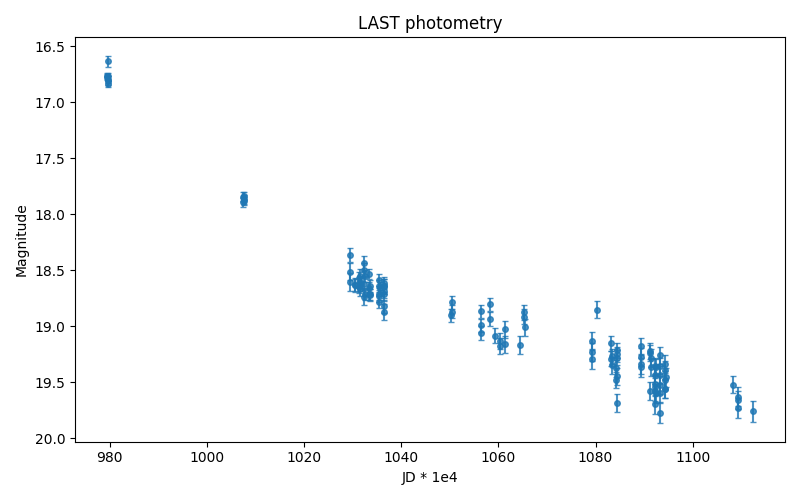

In [82]:
%matplotlib widget
import matplotlib.pyplot as plt
path = "/Users/asaf/Downloads/updated-data-for-2025abdd-from-cast.csv"

df = pd.read_csv(path)

df = df[df['source_name'] == 'LAST'].copy()
ts = pd.to_datetime(df['timestamp'], utc=True, errors='coerce')
df = df[ts.notna()].copy()
df['jd'] = Time(ts.dt.tz_convert('UTC').dt.to_pydatetime(), scale='utc').jd % 1e4
df['mag'] = pd.to_numeric(df['magnitude'].astype(str).str.lstrip('>').str.strip(), errors='coerce')
df['error'] = pd.to_numeric(df['error'].astype(str).str.strip(), errors='coerce')
mask = df['mag'].notna() & df['error'].notna()

plt.figure(figsize=(8, 5))
plt.errorbar(
    df.loc[mask, 'jd'],
    df.loc[mask, 'mag'],
    yerr=df.loc[mask, 'error'],
    fmt='o',
    ms=4,
    capsize=2,
    alpha=0.8
)
plt.gca().invert_yaxis()
plt.xlabel("JD * 1e4")
plt.ylabel("Magnitude")
plt.title("LAST photometry")
plt.tight_layout()
plt.show()